<a href="https://colab.research.google.com/github/JeysonCarmona/PPMI_INVESTIGATION/blob/main/PPMI_ORGANIZACION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  PPMI / IDA — Organización de Datos para ML
> **Proyecto:** Machine Learning — Parkinson's Disease  
> **Plataformas:** IDA (Imaging Data Archive · MJFF) + PPMI + PDBP (NINDS)  
> **Fecha de corte de datos:** 23 de Mayo, 2026  
> **Autor:** Equipo de Investigación

---

##  Descripción del Notebook

Este notebook organiza, limpia y explora los datasets disponibles del estudio PPMI:

| Dataset | Archivo | Descripción |
|---------|---------|-------------|
| IDA Images | `idaSearch_5_23_2026.csv` | Registros de imagen por paciente |
| Participant Status | `Participant_Status_23May2026.csv` | Estado de enrolamiento por paciente |
| Demographics | `Demographics_23May2026.csv` | Variables demográficas |
| MDS-UPDRS Part I | `MDS-UPDRS_Part_I_23May2026.csv` | Evaluación no motora (clínico) |
| MDS-UPDRS Part I PQ | `MDS-UPDRS_Part_I_Patient_Questionnaire_23May2026.csv` | Cuestionario no motor (paciente) |
| MDS-UPDRS Part II | `MDS_UPDRS_Part_II__Patient_Questionnaire_23May2026.csv` | Cuestionario motor (paciente) |
| MDS-UPDRS Part III | `MDS-UPDRS_Part_III_23May2026.csv` | Evaluación motora (clínico) |

---

##  Índice
1. [Instalación e importaciones](#1-instalacion)
2. [Carga de datos](#2-carga)
3. [Dataset IDA — Imágenes](#3-ida)
4. [Participant Status — Estado de pacientes](#4-status)
5. [Demographics](#5-demographics)
6. [MDS-UPDRS (Partes I–III)](#6-updrs)
7. [Dataset integrado (merge)](#7-merge)
8. [Análisis Exploratorio (EDA)](#8-eda)
9. [Exportar dataset limpio para ML](#9-export)


## 1. Instalación e importaciones <a name='1-instalacion'></a>

In [ ]:
# ── Instalación de librerías adicionales (solo si es necesario)
# !pip install -q plotly kaleido

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Estilo de visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
PALETTE = ['#2E86AB', '#7C3AED', '#10B981', '#F59E0B', '#EF4444']

print(' Librerías cargadas correctamente')
print(f'   pandas {pd.__version__} · numpy {np.__version__}')

 Librerías cargadas correctamente
   pandas 2.2.2 · numpy 2.0.2


## 2. Carga de datos <a name='2-carga'></a>

> **Instrucciones:** Sube los archivos CSV a Google Colab con el botón de archivos ( en el panel izquierdo) o monta tu Google Drive.

In [ ]:
# ── Opción A: Cargar desde Google Drive (recomendado)
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/PPMI_Data/'  # ajusta la ruta

# ── Opción B: Cargar directamente (archivos subidos a Colab)
DATA_PATH = '/content/'   # cambia si los archivos están en subcarpeta

# ── Diccionario de archivos
FILES = {
    'ida':      'idaSearch_5_23_2026 (2).csv',
    'status':   'Participant_Status_23May2026 (1).csv',
    'demo':     'Demographics_23May2026.csv',
    'updrs1':   'MDS-UPDRS_Part_I_23May2026.csv',
    'updrs1pq': 'MDS-UPDRS_Part_I_Patient_Questionnaire_23May2026.csv',
    'updrs2':   'MDS_UPDRS_Part_II__Patient_Questionnaire_23May2026.csv',
    'updrs3':   'MDS-UPDRS_Part_III_23May2026.csv',
}

dfs = {}
for key, fname in FILES.items():
    try:
        dfs[key] = pd.read_csv(DATA_PATH + fname, low_memory=False)
        print(f' {key:10s} → {dfs[key].shape[0]:>6,} filas × {dfs[key].shape[1]:>3} cols  |  {fname}')
    except FileNotFoundError:
        print(f' {key:10s} → Archivo no encontrado: {fname}')

print('\n Datasets cargados:', list(dfs.keys()))

✅ ida        → 15,326 filas ×   4 cols  |  idaSearch_5_23_2026 (2).csv
✅ status     →  8,619 filas ×  33 cols  |  Participant_Status_23May2026 (1).csv
✅ demo       →  8,561 filas ×  29 cols  |  Demographics_23May2026.csv
✅ updrs1     → 32,326 filas ×  15 cols  |  MDS-UPDRS_Part_I_23May2026.csv
✅ updrs1pq   → 36,060 filas ×  16 cols  |  MDS-UPDRS_Part_I_Patient_Questionnaire_23May2026.csv
✅ updrs2     → 36,061 filas ×  22 cols  |  MDS_UPDRS_Part_II__Patient_Questionnaire_23May2026.csv
✅ updrs3     → 38,051 filas ×  65 cols  |  MDS-UPDRS_Part_III_23May2026.csv

📁 Datasets cargados: ['ida', 'status', 'demo', 'updrs1', 'updrs1pq', 'updrs2', 'updrs3']


## 3. Dataset IDA — Imágenes <a name='3-ida'></a>

**Clave:** `Subject ID` = identificador único del paciente.  
Un mismo `Subject ID` aparece múltiples veces porque tiene múltiples estudios de imagen (visitas longitudinales o diferentes secuencias MRI). Cada fila = 1 registro de imagen, **no** un paciente nuevo.

In [ ]:
ida = dfs['ida'].copy()
print('=== DATASET IDA (Imágenes) ===')
print(f'Total de registros de imagen : {len(ida):,}')
print(f'Pacientes únicos (Subject ID): {ida["Subject ID"].nunique():,}')
print(f'Registros promedio/paciente  : {len(ida)/ida["Subject ID"].nunique():.1f}')
print()
display(ida.head(5))

=== DATASET IDA (Imágenes) ===
Total de registros de imagen : 15,326
Pacientes únicos (Subject ID): 1,525
Registros promedio/paciente  : 10.0



,Subject ID,Sex,Age,Description
0,100001,M,67.4,SAG 3D MPRAGE
1,100001,M,67.4,MIDLINE SAG LOC
2,100001,M,67.4,RESTING STATE FMRI ep2d_fid_basic_bold
3,100001,M,67.4,RESTING STATE FMRI ep2d_fid_basic_bold
4,100001,M,67.4,AX T2 GRE MT


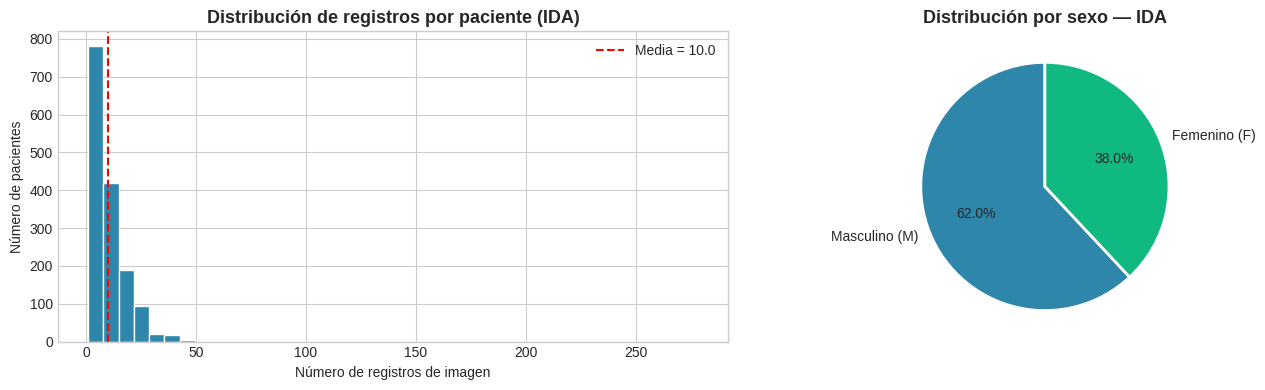


Resumen estadístico — edad (pacientes únicos):


,count,mean,std,min,25%,50%,75%,max
Age,1525.0,62.77,9.97,30.4,56.6,63.9,69.9,85.3


In [ ]:
# ── Verificar que Subject ID se repite (confirma que es longitudinal)
records_per_patient = ida.groupby('Subject ID').size().reset_index(name='n_registros')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de registros por paciente
axes[0].hist(records_per_patient['n_registros'], bins=40, color=PALETTE[0], edgecolor='white')
axes[0].set_title('Distribución de registros por paciente (IDA)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de registros de imagen')
axes[0].set_ylabel('Número de pacientes')
axes[0].axvline(records_per_patient['n_registros'].mean(), color='red', linestyle='--',
                label=f'Media = {records_per_patient["n_registros"].mean():.1f}')
axes[0].legend()

# Distribución por sexo
sex_counts = ida.drop_duplicates('Subject ID')['Sex'].value_counts()
axes[1].pie(sex_counts, labels=['Masculino (M)', 'Femenino (F)'],
            autopct='%1.1f%%', colors=[PALETTE[0], PALETTE[2]],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Distribución por sexo — IDA', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('ida_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nResumen estadístico — edad (pacientes únicos):')
display(ida.drop_duplicates('Subject ID')['Age'].describe().to_frame().T.round(2))

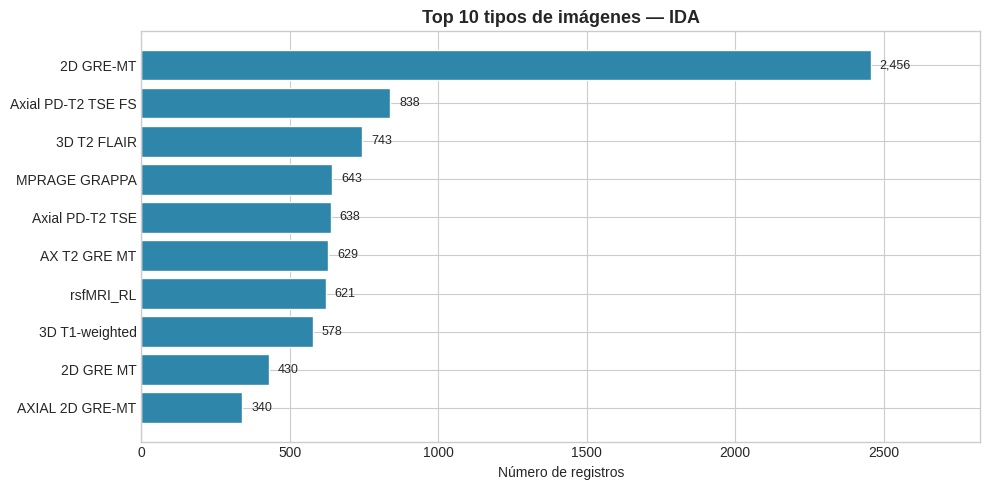

,Tipo de imagen,N registros
0,2D GRE-MT,2456
1,Axial PD-T2 TSE FS,838
2,3D T2 FLAIR,743
3,MPRAGE GRAPPA,643
4,Axial PD-T2 TSE,638
5,AX T2 GRE MT,629
6,rsfMRI_RL,621
7,3D T1-weighted,578
8,2D GRE MT,430
9,AXIAL 2D GRE-MT,340


In [ ]:
# ── Top 10 tipos de imágenes
top_types = ida['Description'].value_counts().head(10).reset_index()
top_types.columns = ['Tipo de imagen', 'N registros']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_types['Tipo de imagen'][::-1], top_types['N registros'][::-1],
               color=PALETTE[0], edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)
ax.set_title('Top 10 tipos de imágenes — IDA', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de registros')
ax.set_xlim(0, top_types['N registros'].max() * 1.15)
plt.tight_layout()
plt.show()

display(top_types)

## 4. Participant Status — Estado de pacientes <a name='4-status'></a>

In [ ]:
status = dfs['status'].copy()
print('=== PARTICIPANT STATUS ===')
print(f'Total de registros (1 por PATNO): {len(status):,}')
print(f'Participantes únicos (PATNO)    : {status["PATNO"].nunique():,}')
print()

print('Estado de enrolamiento:')
display(status['ENROLL_STATUS'].value_counts().rename_axis('Status').reset_index(name='Count'))

print('\nDistribución por cohorte (todos):')
display(status['COHORT_DEFINITION'].value_counts().rename_axis('Cohorte').reset_index(name='Count'))

=== PARTICIPANT STATUS ===
Total de registros (1 por PATNO): 8,619
Participantes únicos (PATNO)    : 8,619

Estado de enrolamiento:


,Status,Count
0,Enrolled,3999
1,Screen failed,3040
2,Withdrew,592
3,Excluded,271
4,Screened,141
5,Pending,140
6,Declined,114
7,Complete,101
8,Withdraw Deceased,84
9,Baseline Withdraw,50



Distribución por cohorte (todos):


,Cohorte,Count
0,Prodromal,5956
1,Parkinson's Disease,2142
2,Healthy Control,440
3,SWEDD,81


Pacientes ENROLLED (activos): 3,999



,Cohorte,N,%
0,Prodromal,2573,64.3
1,Parkinson's Disease,1200,30.0
2,Healthy Control,225,5.6
3,SWEDD,1,0.0


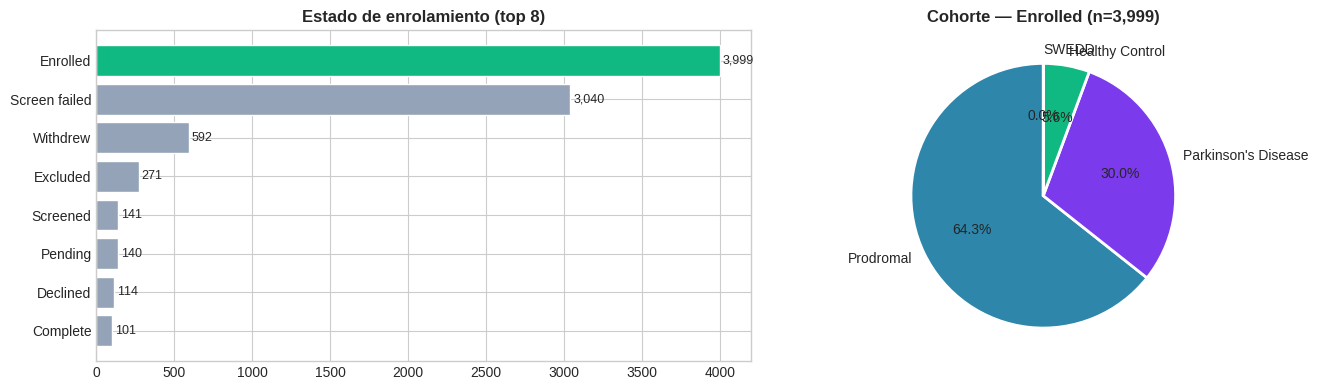

In [ ]:
# ── Enrolled (activos) por cohorte
enrolled = status[status['ENROLL_STATUS'] == 'Enrolled'].copy()
print(f'Pacientes ENROLLED (activos): {len(enrolled):,}')
print()
cohort_enrolled = enrolled['COHORT_DEFINITION'].value_counts().reset_index()
cohort_enrolled.columns = ['Cohorte', 'N']
cohort_enrolled['%'] = (cohort_enrolled['N'] / cohort_enrolled['N'].sum() * 100).round(1)
display(cohort_enrolled)

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Estado de enrolamiento
enroll_counts = status['ENROLL_STATUS'].value_counts().head(8)
colors_enroll = ['#10B981' if s == 'Enrolled' else '#94A3B8' for s in enroll_counts.index]
axes[0].barh(enroll_counts.index[::-1], enroll_counts.values[::-1],
             color=colors_enroll[::-1], edgecolor='white')
axes[0].set_title('Estado de enrolamiento (top 8)', fontsize=12, fontweight='bold')
for i, v in enumerate(enroll_counts.values[::-1]):
    axes[0].text(v + 20, i, f'{v:,}', va='center', fontsize=9)

# Cohortes enrolled
axes[1].pie(cohort_enrolled['N'], labels=cohort_enrolled['Cohorte'],
            autopct='%1.1f%%', colors=PALETTE[:len(cohort_enrolled)],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Cohorte — Enrolled (n=3,999)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('status_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Demographics <a name='5-demographics'></a>

In [ ]:
demo = dfs['demo'].copy()
print('=== DEMOGRAPHICS ===')
print(f'Filas totales         : {len(demo):,}')
print(f'Pacientes únicos      : {demo["PATNO"].nunique():,}')
print(f'Columnas disponibles  : {demo.shape[1]}')
print()

# Tomar una fila por PATNO (la más reciente)
demo_unique = demo.sort_values('LAST_UPDATE', ascending=False).drop_duplicates('PATNO').copy()
print(f'Pacientes únicos (1 fila/PATNO): {len(demo_unique):,}')

# Sexo: 0 = Male, 1 = Female (codificación PPMI)
demo_unique['SEX_LABEL'] = demo_unique['SEX'].map({0.0: 'Masculino', 1.0: 'Femenino'})
print('\nDistribución por sexo:')
display(demo_unique['SEX_LABEL'].value_counts().reset_index())

print('\nEtnicidad hispana/latina:')
display(demo_unique['HISPLAT'].value_counts(dropna=False).rename({0.0: 'No', 1.0: 'Sí'}).reset_index())

display(demo.head(3))

=== DEMOGRAPHICS ===
Filas totales         : 8,561
Pacientes únicos      : 8,561
Columnas disponibles  : 29

Pacientes únicos (1 fila/PATNO): 8,561

Distribución por sexo:


,SEX_LABEL,count
0,Masculino,4449
1,Femenino,4110



Etnicidad hispana/latina:


,HISPLAT,count
0,No,7743
1,Sí,472
2,2.0,279
3,NaN,67


,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,AFICBERB,ASHKJEW,BASQUE,BIRTHDT,SEX,...,HISPLAT,RAASIAN,RABLACK,RAHAWOPI,RAINDALS,RANOS,RAWHITE,RAUNKNOWN,ORIG_ENTRY,LAST_UPDATE
0,IA86904,3000,TRANS,SCREEN,01/2011,0.0,0.0,0.0,12/1941,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,01/2011,2022-11-07 00:00:00
1,IA86905,3001,TRANS,SCREEN,02/2011,0.0,0.0,0.0,01/1946,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,02/2011,2022-11-07 00:00:00
2,IA86906,3002,TRANS,SCREEN,03/2011,0.0,0.0,0.0,08/1943,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,03/2011,2022-11-07 00:00:00


## 6. MDS-UPDRS (Partes I–III) <a name='6-updrs'></a>

La escala **MDS-UPDRS** es la variable clínica principal para ML:
- **Part I**: Aspectos no motores (evaluación clínica)
- **Part I PQ**: Cuestionario de aspectos no motores (autoreportado)
- **Part II**: Cuestionario de aspectos motores cotidianos (autoreportado)
- **Part III**: Evaluación motora (clínico) — **la más importante para ML**

In [ ]:
updrs3 = dfs['updrs3'].copy()
updrs2 = dfs['updrs2'].copy()
updrs1 = dfs['updrs1'].copy()

# Handle case where 'updrs1pq' might not be loaded due to FileNotFoundError
if 'updrs1pq' in dfs:
    updrs1pq = dfs['updrs1pq'].copy()
else:
    print("Warning: 'updrs1pq' not found in dfs. Using an empty DataFrame.")
    updrs1pq = pd.DataFrame(columns=['PATNO'])

print('=== COBERTURA MDS-UPDRS ===')
parts = {
    'Part I (clínico)':      updrs1,
    'Part I PQ (paciente)':  updrs1pq,
    'Part II (paciente)':    updrs2,
    'Part III (clínico)':    updrs3,
}
for name, df in parts.items():
    print(f'  {name:30s} → {len(df):>6,} registros | {df["PATNO"].nunique():>5,} pacientes únicos')

# Pacientes con las 4 partes
# Only include updrs1pq in set intersection if it's not empty
if not updrs1pq.empty:
    all_pats = set(updrs1['PATNO']) & set(updrs1pq['PATNO']) & set(updrs2['PATNO']) & set(updrs3['PATNO'])
else:
    # If updrs1pq is empty, it cannot contribute to 'all_pats' so we exclude it from the intersection
    # or consider it to result in 0 patients with all 4 parts.
    all_pats = set()

print(f'\n  Pacientes con TODAS las partes: {len(all_pats):,}')

=== COBERTURA MDS-UPDRS ===
  Part I (clínico)               → 32,326 registros | 5,126 pacientes únicos
  Part I PQ (paciente)           → 36,060 registros | 5,124 pacientes únicos
  Part II (paciente)             → 36,061 registros | 5,124 pacientes únicos
  Part III (clínico)             → 38,051 registros | 5,131 pacientes únicos

  Pacientes con TODAS las partes: 5,109


Ítems NP3 encontrados: 34 → ['NP3SPCH', 'NP3FACXP', 'NP3RIGN', 'NP3RIGRU', 'NP3RIGLU']...

Registros Baseline con score: 5,193

Distribución score UPDRS3 en Baseline:


,count,mean,std,min,25%,50%,75%,max
UPDRS3_TOTAL,5193.0,24.39,56.0,0.0,4.0,14.0,36.0,3333.0


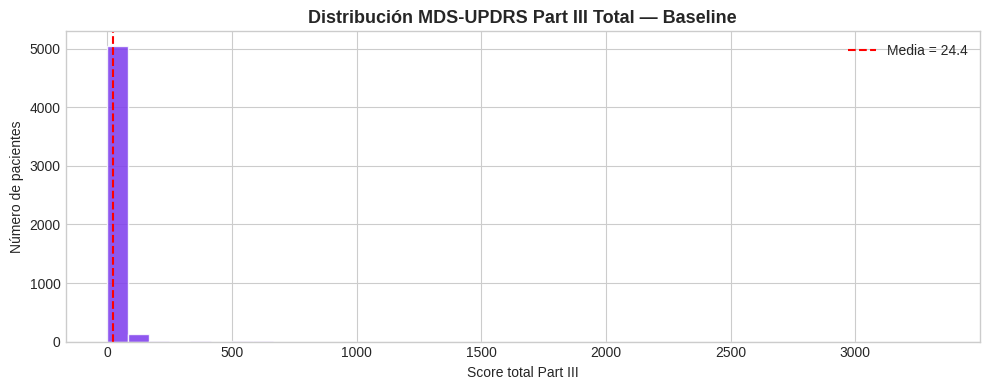

In [ ]:
# ── MDS-UPDRS Part III — Score total (NHY = Hoehn & Yahr)
# Calcular total Part III sumando ítems NP3*
np3_cols = [c for c in updrs3.columns if c.startswith('NP3')]
print(f'Ítems NP3 encontrados: {len(np3_cols)} → {np3_cols[:5]}...')

updrs3['UPDRS3_TOTAL'] = updrs3[np3_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)

# Score en Baseline
bl = updrs3[updrs3['EVENT_ID'] == 'BL'][['PATNO', 'UPDRS3_TOTAL', 'NHY']].dropna()
print(f'\nRegistros Baseline con score: {len(bl):,}')
print('\nDistribución score UPDRS3 en Baseline:')
display(bl['UPDRS3_TOTAL'].describe().round(2).to_frame().T)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(bl['UPDRS3_TOTAL'].dropna(), bins=40, color=PALETTE[1], edgecolor='white', alpha=0.85)
ax.axvline(bl['UPDRS3_TOTAL'].mean(), color='red', linestyle='--',
           label=f'Media = {bl["UPDRS3_TOTAL"].mean():.1f}')
ax.set_title('Distribución MDS-UPDRS Part III Total — Baseline', fontsize=13, fontweight='bold')
ax.set_xlabel('Score total Part III')
ax.set_ylabel('Número de pacientes')
ax.legend()
plt.tight_layout()
plt.savefig('updrs3_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

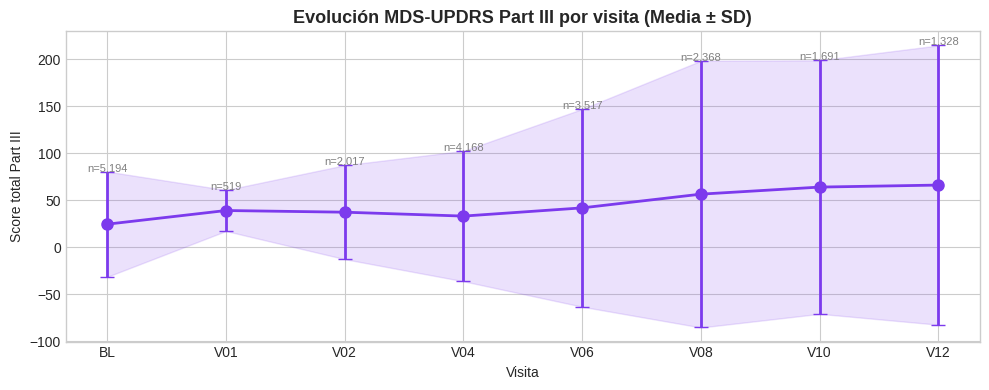

,Visita,Media,N,SD
0,BL,24.38,5194,55.99
1,V01,38.92,519,21.80
2,V02,37.13,2017,49.96
3,V04,32.99,4168,69.33
4,V06,41.73,3517,105.16
5,V08,56.34,2368,141.86
6,V10,63.84,1691,134.84
7,V12,65.98,1328,148.56


In [ ]:
# ── Evolución temporal de UPDRS3 (primeras visitas)
visit_order = ['BL', 'V01', 'V02', 'V04', 'V06', 'V08', 'V10', 'V12']
visit_means = []
for v in visit_order:
    subset = updrs3[updrs3['EVENT_ID'] == v]['UPDRS3_TOTAL'].dropna()
    if len(subset) > 10:
        visit_means.append({'Visita': v, 'Media': subset.mean(), 'N': len(subset), 'SD': subset.std()})

vm_df = pd.DataFrame(visit_means)
if not vm_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.errorbar(vm_df['Visita'], vm_df['Media'], yerr=vm_df['SD'],
                fmt='-o', color=PALETTE[1], capsize=5, linewidth=2, markersize=8)
    ax.fill_between(vm_df['Visita'],
                    vm_df['Media'] - vm_df['SD'],
                    vm_df['Media'] + vm_df['SD'],
                    alpha=0.15, color=PALETTE[1])
    for i, row in vm_df.iterrows():
        ax.annotate(f"n={row['N']:,}", (row['Visita'], row['Media'] + row['SD'] + 0.5),
                    fontsize=8, ha='center', color='gray')
    ax.set_title('Evolución MDS-UPDRS Part III por visita (Media ± SD)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Visita')
    ax.set_ylabel('Score total Part III')
    plt.tight_layout()
    plt.savefig('updrs3_evolution.png', dpi=150, bbox_inches='tight')
    plt.show()
    display(vm_df.round(2))

## 7. Dataset integrado (merge) <a name='7-merge'></a>

Construimos un dataset unificado usando `PATNO` como llave.  
Para ML usamos el **Baseline (BL)** como punto de partida.

In [ ]:
# ── Base: pacientes únicos con status
base = status[['PATNO', 'COHORT', 'COHORT_DEFINITION', 'ENROLL_DATE',
               'ENROLL_STATUS', 'ENROLL_AGE']].copy()

# ── Demographics (1 fila/paciente)
demo_bl = (demo.sort_values('LAST_UPDATE', ascending=False)
               .drop_duplicates('PATNO')
               [['PATNO', 'SEX', 'HISPLAT', 'RAWHITE', 'RABLACK', 'RAASIAN', 'HANDED', 'BIRTHDT']])

# ── UPDRS3 Baseline
updrs3_bl = (updrs3[updrs3['EVENT_ID'] == 'BL']
               [['PATNO', 'UPDRS3_TOTAL', 'NHY', 'PDTRTMNT', 'PDSTATE']]
               .drop_duplicates('PATNO'))

# ── UPDRS1 Baseline (score total NP1RTOT si existe, o suma)
np1_cols = [c for c in updrs1.columns if c.startswith('NP1') and c != 'NP1RTOT']
updrs1['UPDRS1_TOTAL'] = updrs1[np1_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)
updrs1_bl = (updrs1[updrs1['EVENT_ID'] == 'BL']
               [['PATNO', 'UPDRS1_TOTAL']].drop_duplicates('PATNO'))

# ── UPDRS2 Baseline (score total)
np2_cols = [c for c in updrs2.columns if c.startswith('NP2')]
updrs2['UPDRS2_TOTAL'] = updrs2[np2_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)
updrs2_bl = (updrs2[updrs2['EVENT_ID'] == 'BL']
               [['PATNO', 'UPDRS2_TOTAL']].drop_duplicates('PATNO'))

# ── IDA — imágenes disponibles por paciente
ida_summary = (ida.groupby('Subject ID')
                  .agg(n_images=('Description', 'count'),
                       image_types=('Description', lambda x: ', '.join(x.unique()[:3])))
                  .reset_index()
                  .rename(columns={'Subject ID': 'PATNO'}))

# ── Merge
ml_df = (base
         .merge(demo_bl,    on='PATNO', how='left')
         .merge(updrs3_bl,  on='PATNO', how='left')
         .merge(updrs1_bl,  on='PATNO', how='left')
         .merge(updrs2_bl,  on='PATNO', how='left')
         .merge(ida_summary, on='PATNO', how='left'))

# Calcular score UPDRS total (I + II + III)
ml_df['UPDRS_TOTAL'] = ml_df[['UPDRS1_TOTAL', 'UPDRS2_TOTAL', 'UPDRS3_TOTAL']].sum(axis=1, min_count=1)
# Flag de imágenes disponibles
ml_df['HAS_IMAGING'] = ml_df['n_images'].notna().astype(int)

print('=== DATASET INTEGRADO ===')
print(f'Total de pacientes : {len(ml_df):,}')
print(f'Columnas           : {ml_df.shape[1]}')
print(f'Con imágenes IDA   : {ml_df["HAS_IMAGING"].sum():,}')
print(f'Con UPDRS3 BL      : {ml_df["UPDRS3_TOTAL"].notna().sum():,}')
print()
display(ml_df.head(5))

=== DATASET INTEGRADO ===
Total de pacientes : 8,619
Columnas           : 23
Con imágenes IDA   : 1,525
Con UPDRS3 BL      : 4,886



,PATNO,COHORT,COHORT_DEFINITION,ENROLL_DATE,ENROLL_STATUS,ENROLL_AGE,SEX,HISPLAT,RAWHITE,RABLACK,...,UPDRS3_TOTAL,NHY,PDTRTMNT,PDSTATE,UPDRS1_TOTAL,UPDRS2_TOTAL,n_images,image_types,UPDRS_TOTAL,HAS_IMAGING
0,3000,2,Healthy Control,02/2011,Withdrew,69.1,0.0,0.0,1.0,0.0,...,8.0,0.0,NaN,NaN,3.0,0.0,2.0,"AX T2 FLAIR, sag 3D FSPGR BRAVO straight",11.0,1
1,3001,1,Parkinson's Disease,03/2011,Withdrew,65.1,1.0,0.0,1.0,0.0,...,24.0,1.0,0.0,NaN,0.0,4.0,3.0,"AX T2 FLAIR 5/1, AX T2 AC-PC line Entire Brain...",28.0,1
2,3002,1,Parkinson's Disease,03/2011,Withdrew,67.6,0.0,0.0,1.0,0.0,...,34.0,2.0,0.0,NaN,3.0,30.0,3.0,"sag 3D FSPGR BRAVO straight, AX T2 AC-PC line ...",67.0,1
3,3003,1,Parkinson's Disease,04/2011,Enrolled,56.7,0.0,0.0,1.0,0.0,...,58.0,2.0,0.0,NaN,1.0,12.0,3.0,"sag 3D FSPGR BRAVO straight, AX T2 FLAIR 5/1, ...",71.0,1
4,3004,2,Healthy Control,04/2011,Enrolled,59.4,1.0,0.0,1.0,0.0,...,4.0,0.0,NaN,NaN,0.0,0.0,3.0,"sag 3D FSPGR BRAVO straight, AX T2 FLAIR 5/1, ...",4.0,1


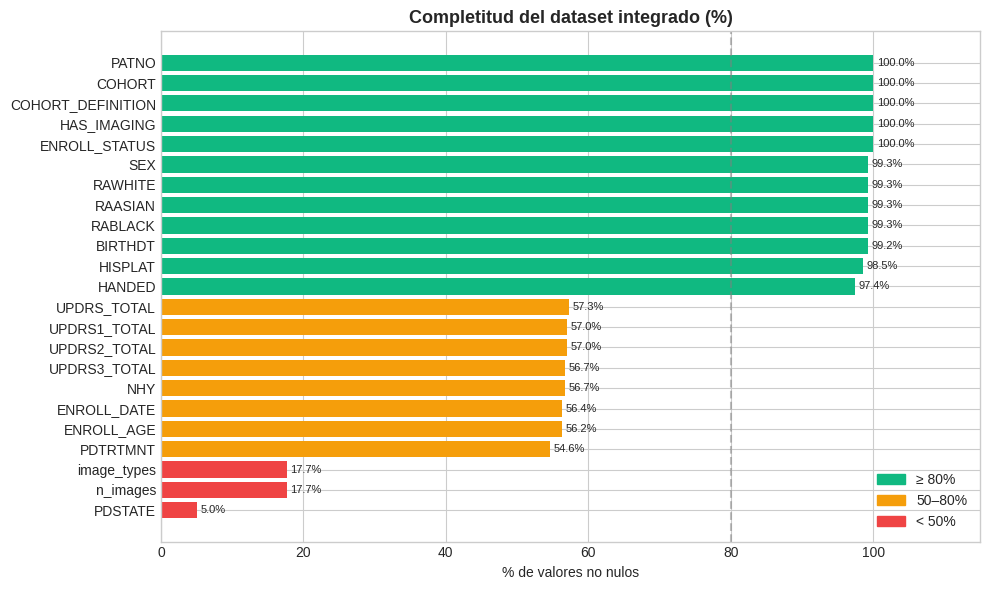

In [ ]:
# ── Completitud del dataset
completeness = ml_df.notna().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(completeness.index[::-1], completeness.values[::-1],
               color=[PALETTE[2] if v >= 80 else PALETTE[3] if v >= 50 else PALETTE[4]
                      for v in completeness.values[::-1]])
ax.axvline(80, color='gray', linestyle='--', alpha=0.5, label='80% umbral')
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=8)
ax.set_xlim(0, 115)
ax.set_title('Completitud del dataset integrado (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('% de valores no nulos')

green_patch = mpatches.Patch(color=PALETTE[2], label='≥ 80%')
orange_patch = mpatches.Patch(color=PALETTE[3], label='50–80%')
red_patch = mpatches.Patch(color=PALETTE[4], label='< 50%')
ax.legend(handles=[green_patch, orange_patch, red_patch], loc='lower right')

plt.tight_layout()
plt.savefig('completeness.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análisis Exploratorio (EDA) <a name='8-eda'></a>

Pacientes enrolled con UPDRS3 BL: 3,961


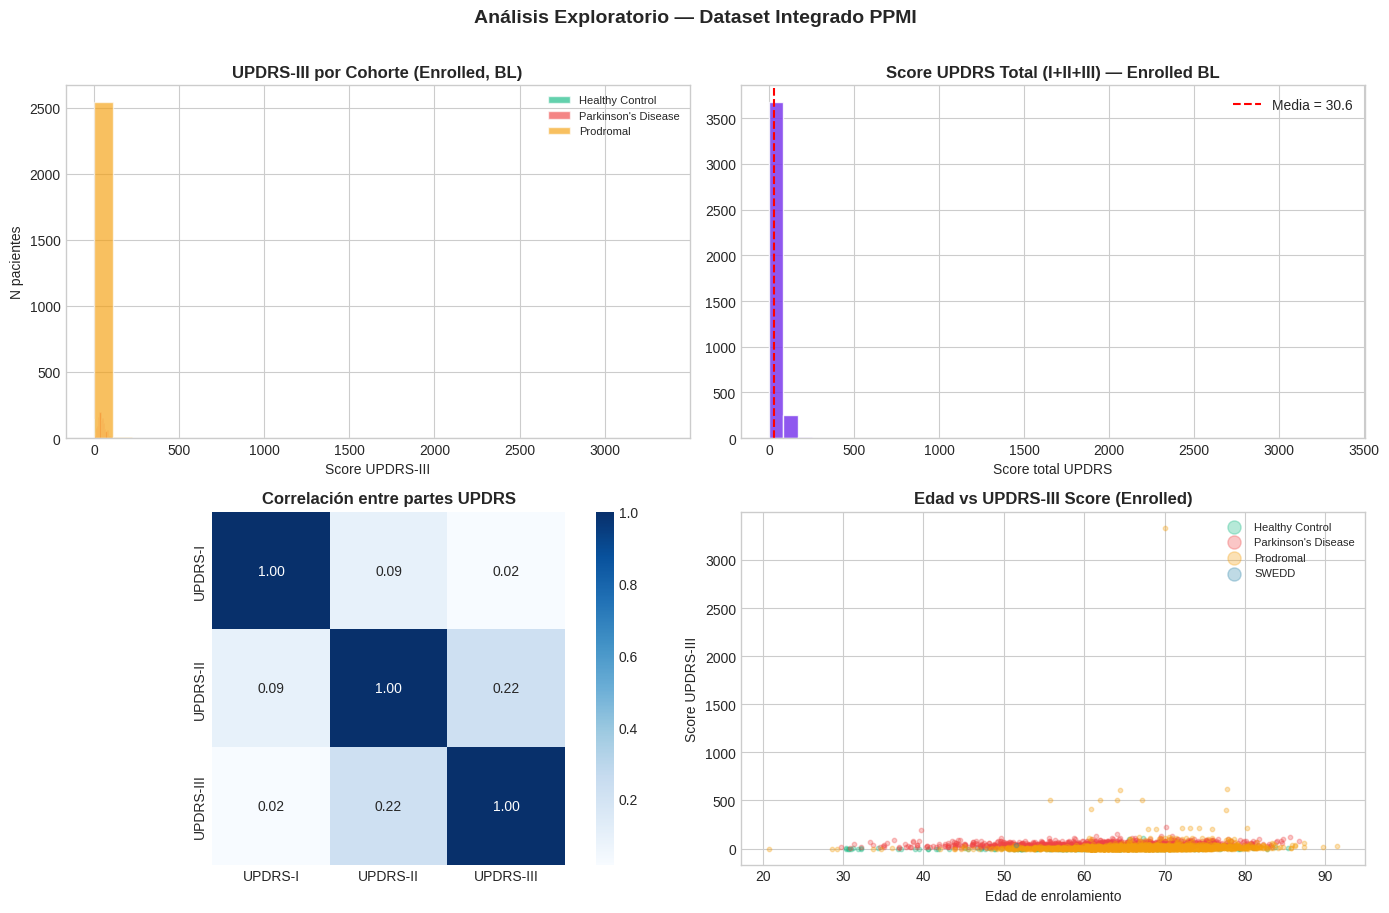

In [ ]:
# ── Solo enrolled con UPDRS3
ml_enrolled = ml_df[(ml_df['ENROLL_STATUS'] == 'Enrolled') & (ml_df['UPDRS3_TOTAL'].notna())].copy()
print(f'Pacientes enrolled con UPDRS3 BL: {len(ml_enrolled):,}')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. UPDRS3 por cohorte
cohorts_plot = ml_enrolled[ml_enrolled['COHORT_DEFINITION'].isin(
    ['Parkinson\'s Disease', 'Healthy Control', 'Prodromal'])]
colors_map = {"Parkinson's Disease": PALETTE[4], 'Healthy Control': PALETTE[2], 'Prodromal': PALETTE[3]}
for cohort, grp in cohorts_plot.groupby('COHORT_DEFINITION'):
    axes[0,0].hist(grp['UPDRS3_TOTAL'], bins=30, alpha=0.65,
                   label=cohort, color=colors_map.get(cohort, PALETTE[0]), edgecolor='white')
axes[0,0].set_title('UPDRS-III por Cohorte (Enrolled, BL)', fontweight='bold')
axes[0,0].set_xlabel('Score UPDRS-III')
axes[0,0].set_ylabel('N pacientes')
axes[0,0].legend(fontsize=8)

# 2. UPDRS total
axes[0,1].hist(ml_enrolled['UPDRS_TOTAL'].dropna(), bins=40,
               color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[0,1].axvline(ml_enrolled['UPDRS_TOTAL'].mean(), color='red', linestyle='--',
                  label=f'Media = {ml_enrolled["UPDRS_TOTAL"].mean():.1f}')
axes[0,1].set_title('Score UPDRS Total (I+II+III) — Enrolled BL', fontweight='bold')
axes[0,1].set_xlabel('Score total UPDRS')
axes[0,1].legend()

# 3. Correlación UPDRS1, 2, 3
corr_data = ml_enrolled[['UPDRS1_TOTAL', 'UPDRS2_TOTAL', 'UPDRS3_TOTAL']].dropna()
corr_matrix = corr_data.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues',
            square=True, ax=axes[1,0],
            xticklabels=['UPDRS-I', 'UPDRS-II', 'UPDRS-III'],
            yticklabels=['UPDRS-I', 'UPDRS-II', 'UPDRS-III'])
axes[1,0].set_title('Correlación entre partes UPDRS', fontweight='bold')

# 4. UPDRS3 vs edad de enrolamiento
age_updrs = ml_enrolled[['ENROLL_AGE', 'UPDRS3_TOTAL', 'COHORT_DEFINITION']].dropna()
for cohort, grp in age_updrs.groupby('COHORT_DEFINITION'):
    axes[1,1].scatter(grp['ENROLL_AGE'], grp['UPDRS3_TOTAL'],
                      alpha=0.3, s=10, label=cohort, color=colors_map.get(cohort, PALETTE[0]))
axes[1,1].set_title('Edad vs UPDRS-III Score (Enrolled)', fontweight='bold')
axes[1,1].set_xlabel('Edad de enrolamiento')
axes[1,1].set_ylabel('Score UPDRS-III')
axes[1,1].legend(fontsize=8, markerscale=3)

plt.suptitle('Análisis Exploratorio — Dataset Integrado PPMI', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Exportar dataset limpio para ML <a name='9-export'></a>

In [ ]:
# ── Dataset ML: enrolled, con UPDRS3, variables relevantes
ml_cols = [
    'PATNO', 'COHORT', 'COHORT_DEFINITION', 'ENROLL_STATUS', 'ENROLL_AGE',
    'SEX', 'HISPLAT', 'RAWHITE', 'RABLACK', 'RAASIAN', 'HANDED',
    'UPDRS1_TOTAL', 'UPDRS2_TOTAL', 'UPDRS3_TOTAL', 'UPDRS_TOTAL',
    'NHY', 'PDTRTMNT', 'PDSTATE',
    'HAS_IMAGING', 'n_images'
]

# Filtrar columnas disponibles
available_cols = [c for c in ml_cols if c in ml_df.columns]
ml_final = ml_df[available_cols].copy()

# Etiqueta binaria para clasificación: PD vs No PD
ml_final['LABEL_PD'] = (ml_final['COHORT_DEFINITION'] == "Parkinson's Disease").astype(int)

print('=== DATASET FINAL PARA ML ===')
print(f'Filas    : {len(ml_final):,}')
print(f'Columnas : {ml_final.shape[1]}')
print(f'\nDistribución de etiqueta (LABEL_PD):')
display(ml_final['LABEL_PD'].value_counts().rename({0: 'No PD', 1: 'PD'}).reset_index())

print(f'\nNulos por columna:')
nulls = ml_final.isnull().sum()
display(nulls[nulls > 0].sort_values(ascending=False).to_frame('Nulls').assign(Pct=lambda x: (x['Nulls']/len(ml_final)*100).round(1)))

# Exportar
output_file = '/content/PPMI_ML_Dataset_May2026.csv'
ml_final.to_csv(output_file, index=False)
print(f'\n✅ Dataset exportado: {output_file}')
print(f'   {len(ml_final):,} pacientes × {ml_final.shape[1]} variables')
display(ml_final.head(5))

=== DATASET FINAL PARA ML ===
Filas    : 8,619
Columnas : 21

Distribución de etiqueta (LABEL_PD):


,LABEL_PD,count
0,No PD,6477
1,PD,2142



Nulos por columna:


,Nulls,Pct
PDSTATE,8185,95.0
n_images,7094,82.3
PDTRTMNT,3914,45.4
ENROLL_AGE,3771,43.8
NHY,3734,43.3
UPDRS3_TOTAL,3733,43.3
UPDRS2_TOTAL,3708,43.0
UPDRS1_TOTAL,3704,43.0
UPDRS_TOTAL,3684,42.7
HANDED,221,2.6



✅ Dataset exportado: /content/PPMI_ML_Dataset_May2026.csv
   8,619 pacientes × 21 variables


,PATNO,COHORT,COHORT_DEFINITION,ENROLL_STATUS,ENROLL_AGE,SEX,HISPLAT,RAWHITE,RABLACK,RAASIAN,...,UPDRS1_TOTAL,UPDRS2_TOTAL,UPDRS3_TOTAL,UPDRS_TOTAL,NHY,PDTRTMNT,PDSTATE,HAS_IMAGING,n_images,LABEL_PD
0,3000,2,Healthy Control,Withdrew,69.1,0.0,0.0,1.0,0.0,0.0,...,3.0,0.0,8.0,11.0,0.0,NaN,NaN,1,2.0,0
1,3001,1,Parkinson's Disease,Withdrew,65.1,1.0,0.0,1.0,0.0,0.0,...,0.0,4.0,24.0,28.0,1.0,0.0,NaN,1,3.0,1
2,3002,1,Parkinson's Disease,Withdrew,67.6,0.0,0.0,1.0,0.0,0.0,...,3.0,30.0,34.0,67.0,2.0,0.0,NaN,1,3.0,1
3,3003,1,Parkinson's Disease,Enrolled,56.7,0.0,0.0,1.0,0.0,0.0,...,1.0,12.0,58.0,71.0,2.0,0.0,NaN,1,3.0,1
4,3004,2,Healthy Control,Enrolled,59.4,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,4.0,4.0,0.0,NaN,NaN,1,3.0,0


In [ ]:
# ── Resumen final del inventario de datos
print('=' * 60)
print('INVENTARIO FINAL DE DATOS — MAYO 2026')
print('=' * 60)

summary = [
    ('IDA — Registros de imagen', f"{len(dfs['ida']):,}"),
    ('IDA — Pacientes únicos (Subject ID)', f"{dfs['ida']['Subject ID'].nunique():,}"),
    ('PPMI — Total participantes', f"{len(dfs['status']):,}"),
    ('PPMI — Enrolled (activos)', f"{(dfs['status']['ENROLL_STATUS'] == 'Enrolled').sum():,}"),
    ('PPMI — Parkinson Disease (enrolled)', f"{( (dfs['status']['ENROLL_STATUS'] == 'Enrolled') & (dfs['status']['COHORT_DEFINITION'] == "Parkinson's Disease") ).sum():,}"),
    ('PPMI — Prodromal (enrolled)', f"{( (dfs['status']['ENROLL_STATUS'] == 'Enrolled') & (dfs['status']['COHORT_DEFINITION'] == 'Prodromal') ).sum():,}"),
    ('PPMI — Healthy Control (enrolled)', f"{( (dfs['status']['ENROLL_STATUS'] == 'Enrolled') & (dfs['status']['COHORT_DEFINITION'] == 'Healthy Control') ).sum():,}"),
    ('MDS-UPDRS Part III — Pacientes únicos', f"{dfs['updrs3']['PATNO'].nunique():,}"),
    ('MDS-UPDRS Completo (4 partes) — Pacientes', f"{len(all_pats):,}"),
    ('Dataset ML integrado — Filas', f"{len(ml_final):,}"),
]

for label, value in summary:
    print(f'  {label:<50s}: {value:>8}')

print('=' * 60)
print('  PDBP — Acceso pendiente (pdbp.ninds.nih.gov)')
print('  AMP PD — 4,298 pacientes (amp-pd.org)')
print('=' * 60)

INVENTARIO FINAL DE DATOS — MAYO 2026
  IDA — Registros de imagen                         :   15,326
  IDA — Pacientes únicos (Subject ID)               :    1,525
  PPMI — Total participantes                        :    8,619
  PPMI — Enrolled (activos)                         :    3,999
  PPMI — Parkinson Disease (enrolled)               :    1,200
  PPMI — Prodromal (enrolled)                       :    2,573
  PPMI — Healthy Control (enrolled)                 :      225
  MDS-UPDRS Part III — Pacientes únicos             :    5,131
  MDS-UPDRS Completo (4 partes) — Pacientes         :    5,109
  Dataset ML integrado — Filas                      :    8,619
  PDBP — Acceso pendiente (pdbp.ninds.nih.gov)
  AMP PD — 4,298 pacientes (amp-pd.org)
